In [91]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [92]:
df = pd.read_csv("customer_churn.csv")
print(df)

     age        income  credit_score  transactions_month  avg_purchase_value  \
0     56           NaN    770.887470                  29           84.828689   
1     69  53051.954538    622.025467                  41          133.943805   
2     46  38654.738821    665.727931                  36          114.993023   
3     32  28666.194356    715.281358                  29          153.875284   
4     60  40301.406736           NaN                  27          115.391031   
..   ...           ...           ...                 ...                 ...   
995   60  56292.986659    751.728246                  26          149.322171   
996   64  36687.617333    556.297594                  40           44.289513   
997   62  43438.125495    698.504304                  33          132.459634   
998   35  60835.720367    607.589743                  49           72.489390   
999   55  44407.502719    770.356453                  36          104.107070   

     days_since_last_login  tenure_mont

In [93]:
df.head()

,age,income,credit_score,transactions_month,avg_purchase_value,days_since_last_login,tenure_months,num_products,gender,region,churn
0,56,NaN,770.887470,29,84.828689,143,90,1,Male,South,1
1,69,53051.954538,622.025467,41,133.943805,72,96,4,Female,East,1
2,46,38654.738821,665.727931,36,114.993023,155,88,3,Male,North,1
3,32,28666.194356,715.281358,29,153.875284,76,110,2,Male,South,0
4,60,40301.406736,NaN,27,115.391031,168,99,2,Male,East,1


In [94]:
df.info

<bound method DataFrame.info of      age        income  credit_score  transactions_month  avg_purchase_value  \
0     56           NaN    770.887470                  29           84.828689   
1     69  53051.954538    622.025467                  41          133.943805   
2     46  38654.738821    665.727931                  36          114.993023   
3     32  28666.194356    715.281358                  29          153.875284   
4     60  40301.406736           NaN                  27          115.391031   
..   ...           ...           ...                 ...                 ...   
995   60  56292.986659    751.728246                  26          149.322171   
996   64  36687.617333    556.297594                  40           44.289513   
997   62  43438.125495    698.504304                  33          132.459634   
998   35  60835.720367    607.589743                  49           72.489390   
999   55  44407.502719    770.356453                  36          104.107070   

     da

In [95]:
df.describe()

,age,income,credit_score,transactions_month,avg_purchase_value,days_since_last_login,tenure_months,num_products,churn
count,1000.00000,951.000000,950.000000,1000.000000,950.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,43.81900,55354.417513,651.422837,29.842000,119.301574,182.155000,60.394000,3.129000,0.517000
std,14.99103,32708.500386,68.271995,5.453511,39.619144,104.205824,34.163166,1.410088,0.499961
min,18.00000,7271.860691,444.172796,15.000000,-7.068153,0.000000,1.000000,1.000000,0.000000
25%,31.00000,40959.853770,605.096009,26.000000,93.330104,88.000000,31.000000,2.000000,0.000000
50%,44.00000,51298.846812,650.746768,30.000000,119.585761,184.000000,61.000000,3.000000,1.000000
75%,56.00000,61285.465584,697.845647,33.000000,146.374081,273.250000,89.250000,4.000000,1.000000
max,69.00000,254852.478291,873.517530,49.000000,244.516408,364.000000,119.000000,5.000000,1.000000


<Axes: ylabel='income'>

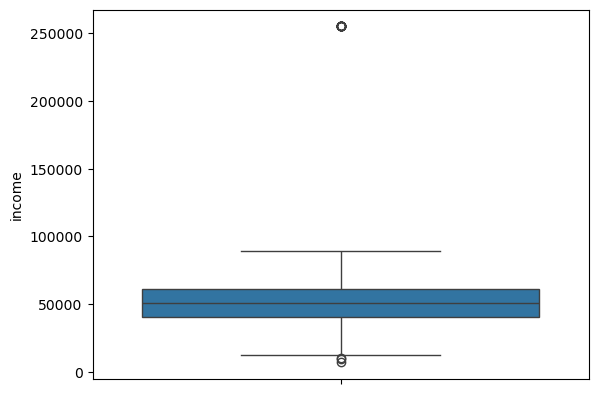

In [96]:
# make the box plot
sns.boxplot(df['income'])

In [97]:
# Step 4: Data preprocessing
# Handle missing values using median of numerical columns

# 1. Find median of income
income_median = df['income'].median()
income_median = round(income_median, 2)

# 2. Find median of credit_score
credit_median = df['credit_score'].median()
credit_median = round(credit_median, 2)

# 3. Find median of purchase_value_med
purchase_median = df['avg_purchase_value'].median()

purchase_median = round(purchase_median, 2)


# Fill missing values

df['credit_score'].fillna(credit_median, inplace=True)

df['income'].fillna(income_median, inplace=True)

df['avg_purchase_value'].fillna(purchase_median, inplace=True)

C:\Users\SANDY\AppData\Local\Temp\ipykernel_4912\3996086765.py:20: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['credit_score'].fillna(credit_median, inplace=True)
C:\Users\SANDY\AppData\Local\Temp\ipykernel_4912\3996086765.py:22: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

F

In [98]:
# Handle the outliers

num_columns = ['income', 'credit_score', 'avg_purchase_value']

for col in num_columns:

    # Find Q1 and Q3
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    # Find IQR
    IQR = Q3 - Q1

    # Find lower and upper bounds
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Find outliers
    outlier = df[
        (df[col] < lower_bound) |
        (df[col] > upper_bound)
    ]

    # Print number of outliers
    print(col, "Outliers:", outlier.shape[0])

    # Handle outliers using clipping
    df[col] = df[col].clip(
        lower=lower_bound,
        upper=upper_bound
    )

income Outliers: 25
credit_score Outliers: 14
avg_purchase_value Outliers: 16


<Axes: ylabel='avg_purchase_value'>

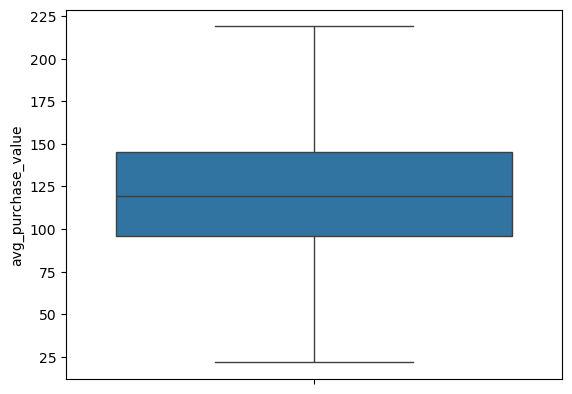

In [99]:
sns.boxplot(df['avg_purchase_value'])

In [100]:
# handle cat col

df['gender'].replace({'Male':1,'Female':0},inplace = True)

C:\Users\SANDY\AppData\Local\Temp\ipykernel_4912\94110808.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['gender'].replace({'Male':1,'Female':0},inplace = True)
C:\Users\SANDY\AppData\Local\Temp\ipykernel_4912\94110808.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['gender'].replace(

In [101]:
df = df.drop('region', axis=1)

In [102]:
# 5: dividen in x and y

X = df.drop('churn',axis =1)
y =df['churn']

In [103]:
#6: splitting dataset into training and testing

from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size =0.20,
    random_state=42

)

In [104]:
# Step 7: Model Building

from sklearn.linear_model import LogisticRegression

# Create the model
LR = LogisticRegression(max_iter=1000)

# Train the model
model = LR.fit(X_train, y_train)

# Make predictions on testing data
y_pred = model.predict(X_test)

print("Predictions:", y_pred)

Predictions: [1 1 1 1 1 1 0 1 1 1 1 1 0 0 1 0 0 0 1 1 0 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1
 0 1 0 1 1 1 0 0 0 1 1 1 0 1 0 1 1 1 0 1 1 1 0 0 1 0 1 0 0 0 1 1 0 1 1 0 1
 1 1 1 1 0 1 1 1 1 0 1 1 1 1 1 0 0 1 0 1 0 0 1 1 1 1 1 0 1 0 1 1 1 1 1 1 0
 1 1 0 0 1 1 1 1 1 1 0 1 1 1 0 1 1 1 1 1 1 1 0 1 1 0 1 1 1 1 1 1 1 1 1 1 1
 1 0 1 1 1 1 1 0 1 1 1 1 0 1 0 0 1 1 1 1 0 1 1 0 1 1 0 0 0 0 0 0 1 0 1 1 1
 1 0 1 1 1 1 1 1 0 1 1 0 1 0 1]


c:\Users\SANDY\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [105]:
# 8 : model Evalution metrics

from sklearn.metrics import accuracy_score

# find the acuuresy
ac = accuracy_score(y_test,y_pred)

print("Accuracy of model",ac)

Accuracy of model 0.53
